# Customer Shopping Behavior Analysis

This project analyzes customer purchasing patterns using Python, data visualization, and machine learning.

The goal is to uncover insights about:
- Customer spending patterns
- Category performance
- Seasonal sales trends
- Customer segmentation
- Purchase prediction

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

## Data Loading

The dataset is loaded into the analysis environment to begin the data exploration process.

Loading the dataset allows us to:
- Verify that the data has been imported correctly
- Preview the initial rows of the dataset
- Prepare the data for further cleaning and analysis

In [38]:
df = pd.read_csv("customer_shopping_behavior.csv")

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## Dataset Overview

The dataset provides information about customer shopping behavior, including demographics and purchasing details.

Examining the dataset structure helps understand:
- The number of records and variables in the dataset
- The types of data stored in each column
- The overall characteristics of the dataset before analysis

In [39]:
df.shape

(3900, 18)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [41]:
df.describe(include="all")

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


## Data Cleaning

Before performing analysis, the dataset must be cleaned to ensure accuracy and consistency.

Data cleaning steps help:
- Identify and handle missing values
- Standardize column names for easier analysis
- Prepare the dataset for reliable data exploration and modeling

In [42]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [43]:
df["Review Rating"] = df.groupby("Category")["Review Rating"].transform(
    lambda x: x.fillna(x.median())
)

In [45]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")

df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount_(usd),location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## Feature Engineering

Feature engineering involves creating new variables from existing data to enhance analysis and interpretation.

In this project, customer ages are categorized into age groups to help:
- Understand demographic distribution more clearly
- Simplify age-based comparisons
- Support customer segmentation analysis

In [46]:
labels = ["Young Adult", "Adult", "Middle Aged", "Senior"]

df["age_group"] = pd.qcut(df["age"], q=4, labels=labels)

df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount_(usd),location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,age_group
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,Middle Aged
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,Young Adult
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Middle Aged
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,Young Adult
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,Middle Aged


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps identify trends, patterns, and relationships within the dataset.

Analyzing the dataset through EDA can provide insights into:
- Customer purchasing behavior and spending patterns
- Differences in sales across product categories
- Demographic factors influencing customer purchases

In [47]:
total_revenue = df["purchase_amount_(usd)"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 233081


## Revenue by Product Category

Analyzing revenue across product categories helps identify which categories generate the highest sales.

This analysis can provide insights into:
- The most profitable product categories
- Customer preferences for different product types
- Opportunities for improving product offerings and inventory planning

In [48]:
category_sales = df.groupby("category")["purchase_amount_(usd)"].sum().sort_values(ascending=False)

category_sales

,purchase_amount_(usd)
category,
Clothing,104264
Accessories,74200
Footwear,36093
Outerwear,18524


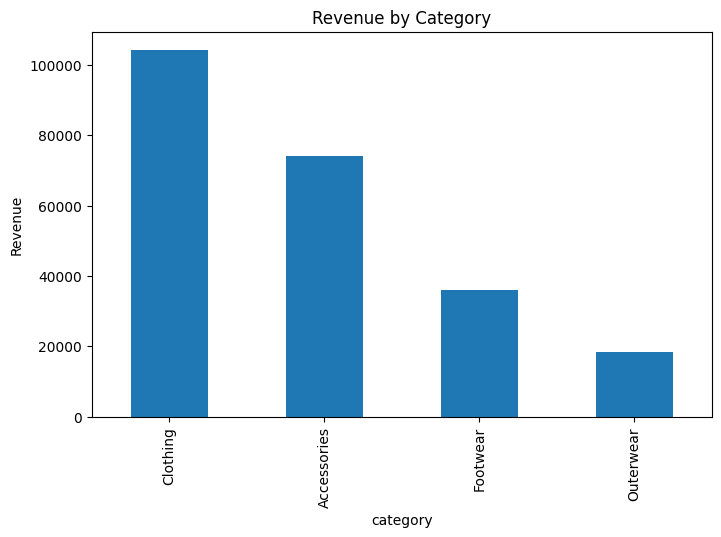

In [49]:
plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")

plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.show()

## Customer Spending by Gender

Understanding spending behavior across genders helps identify differences in purchasing patterns.

Analyzing gender-based spending can provide insights into:
- Whether one gender spends more on average
- Potential demographic differences in purchasing behavior
- Opportunities for targeted marketing strategies

In [50]:
df.groupby("gender")["purchase_amount_(usd)"].mean()

,purchase_amount_(usd)
gender,
Female,60.249199
Male,59.536199


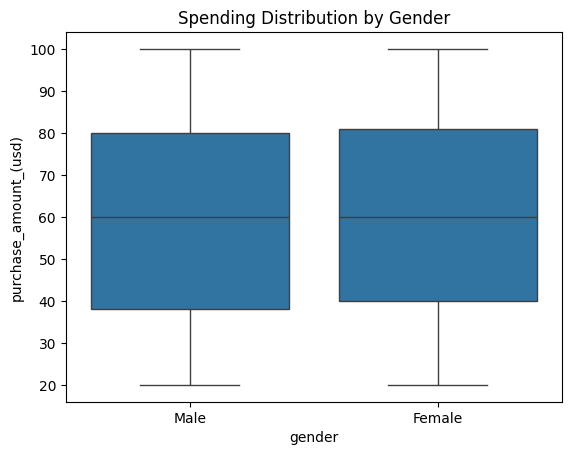

In [51]:
sns.boxplot(x="gender", y="purchase_amount_(usd)", data=df)

plt.title("Spending Distribution by Gender")
plt.show()

## Age Distribution of Customers

Understanding the age distribution helps identify the dominant customer demographics in the dataset.

Analyzing age groups can provide insights into:
- Which age segment contributes most to purchases
- Target demographics for marketing strategies
- Potential customer segmentation opportunities

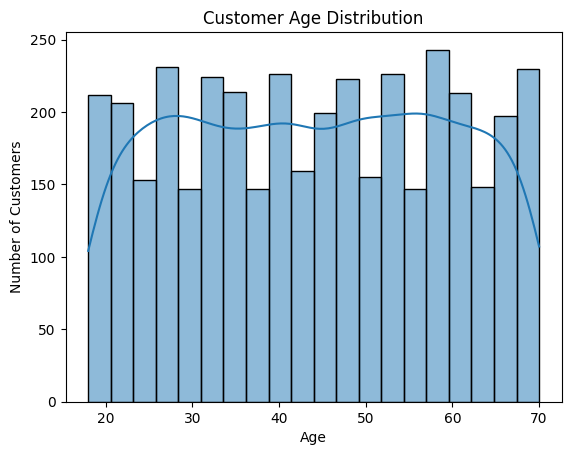

In [53]:
sns.histplot(df["age"], bins=20, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

## Payment Method Analysis

Analyzing payment methods helps understand customer transaction preferences.

This analysis reveals:
- Which payment method is used most frequently
- Customer payment behavior patterns
- Opportunities for businesses to optimize payment options

Understanding preferred payment methods can help businesses improve checkout experiences and promote suitable payment solutions.

In [54]:
payment_counts = df["payment_method"].value_counts()

payment_counts

,count
payment_method,
PayPal,677
Credit Card,671
Cash,670
Debit Card,636
Venmo,634
Bank Transfer,612


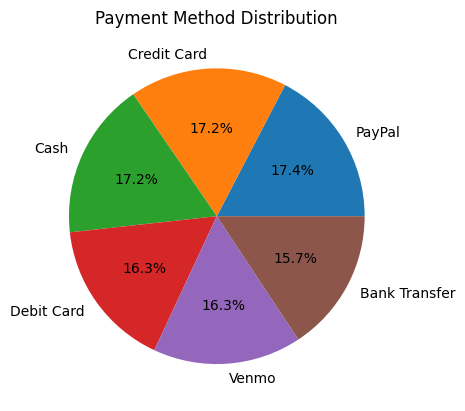

In [55]:
payment_counts.plot(kind="pie", autopct="%1.1f%%")

plt.title("Payment Method Distribution")
plt.ylabel("")

plt.show()

## Seasonal Sales Analysis

Customer purchasing behavior often varies across different seasons.

Analyzing seasonal trends helps businesses:
- Identify peak sales periods
- Plan marketing campaigns during high-demand seasons
- Optimize inventory management

This analysis examines how total purchase amounts vary across seasons.

In [56]:
season_sales = df.groupby("season")["purchase_amount_(usd)"].sum()

season_sales

,purchase_amount_(usd)
season,
Fall,60018
Spring,58679
Summer,55777
Winter,58607


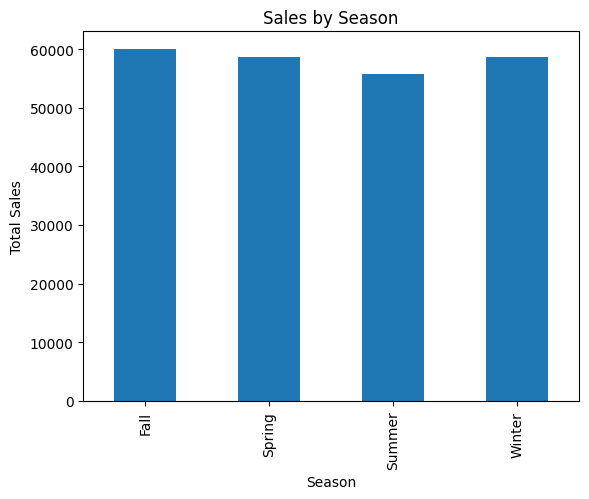

In [57]:
season_sales.plot(kind="bar")

plt.title("Sales by Season")
plt.xlabel("Season")
plt.ylabel("Total Sales")

plt.show()

## Correlation Analysis

Correlation analysis helps identify relationships between numerical variables in the dataset.

A correlation heatmap visually represents the strength of relationships between variables. Values range from -1 to 1:

- **1** → Strong positive relationship
- **0** → No relationship
- **-1** → Strong negative relationship

This analysis helps determine which factors influence purchase amounts and customer behavior.

In [58]:
corr = df.corr(numeric_only=True)

corr

,customer_id,age,purchase_amount_(usd),review_rating,previous_purchases
customer_id,1.000000,-0.004079,0.011048,0.000281,-0.039159
age,-0.004079,1.000000,-0.010424,-0.024463,0.040445
purchase_amount_(usd),0.011048,-0.010424,1.000000,0.029659,0.008063
review_rating,0.000281,-0.024463,0.029659,1.000000,0.003555
previous_purchases,-0.039159,0.040445,0.008063,0.003555,1.000000


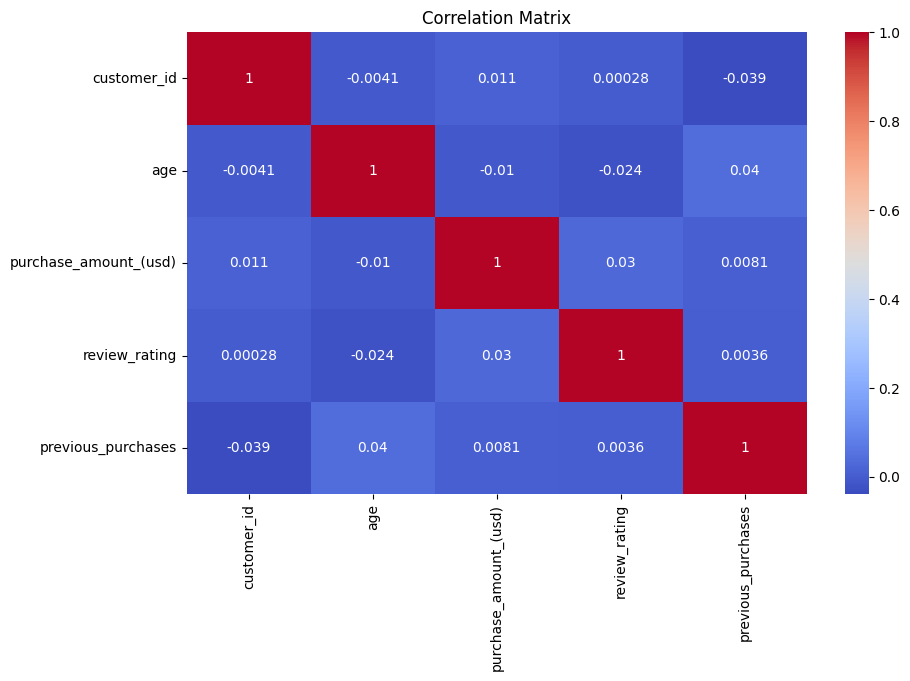

In [59]:
plt.figure(figsize=(10,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

## Customer Segmentation

Customer segmentation helps businesses identify different groups of customers based on purchasing behavior.

In this analysis, we use **RFM-style metrics**:

- **Monetary** → Total purchase amount
- **Recency** → Recent purchasing activity

By scoring customers based on these metrics, businesses can identify:

- High-value customers
- Regular customers
- Low-spending customers

These insights help companies design targeted marketing strategies.

In [60]:
rfm = df.groupby("customer_id").agg({
    "purchase_amount_(usd)": "sum",
    "previous_purchases": "max"
})

rfm.columns = ["monetary","recency"]

rfm.head()

,monetary,recency
customer_id,,
1,53,14
2,64,2
3,73,23
4,90,49
5,49,31


In [61]:
rfm["M_score"] = pd.qcut(rfm["monetary"], 4, labels=[1,2,3,4])
rfm["R_score"] = pd.qcut(rfm["recency"], 4, labels=[4,3,2,1])

rfm["RFM_score"] = rfm[["R_score","M_score"]].sum(axis=1)

rfm.head()

,monetary,recency,M_score,R_score,RFM_score
customer_id,,,,,
1,53,14,2,3,5
2,64,2,3,4,7
3,73,23,3,3,6
4,90,49,4,1,5
5,49,31,2,2,4


## Purchase Amount Prediction

To further analyze customer behavior, we build a machine learning model that predicts purchase amounts based on customer attributes.

The model uses the following features:

- Age
- Gender
- Product Category
- Previous Purchases

We use **Linear Regression**, a simple yet effective model for predicting continuous values.

## Data Preparation for Machine Learning

Machine learning models require numerical inputs. Therefore, categorical variables such as gender, product category, and season must be converted into numerical format.

We use **Label Encoding** to transform these categorical variables into numerical values that the model can process.

In [62]:
le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])
df["category"] = le.fit_transform(df["category"])
df["season"] = le.fit_transform(df["season"])

## Feature Selection

To train the prediction model, we select relevant input variables (features) that may influence purchase amounts.

Selected features:
- Age
- Gender
- Product Category
- Previous Purchases

Target variable:
- Purchase Amount (USD)

In [63]:
X = df[["age","gender","category","previous_purchases"]]

y = df["purchase_amount_(usd)"]

## Train-Test Split

To evaluate model performance, the dataset is divided into:

- **Training Set (80%)** → Used to train the model
- **Testing Set (20%)** → Used to evaluate prediction accuracy

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Training

We train a **Linear Regression model** to predict purchase amounts based on customer attributes.

Linear Regression models the relationship between independent variables and a continuous dependent variable.

In [65]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## Model Prediction

After training, the model predicts purchase amounts for the test dataset.

In [66]:
predictions = model.predict(X_test)

## Model Evaluation

To evaluate the model performance, we use:

- **R² Score** → Measures how well the model explains variance in the data.
- **Root Mean Squared Error (RMSE)** → Measures prediction error.

Higher R² values and lower RMSE values indicate better model performance.

In [67]:
print("R2 Score:", r2_score(y_test, predictions))

print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))

R2 Score: -0.005245322208442538
RMSE: 23.717452680191027


## Customer Spending vs Age

This visualization examines the relationship between customer age and purchase amount.

By plotting purchase amount against age, we can observe whether certain age groups tend to spend more than others.

Key objectives of this analysis:
- Identify spending patterns across different age groups
- Detect potential correlations between age and purchase amount
- Support targeted marketing strategies based on customer demographics

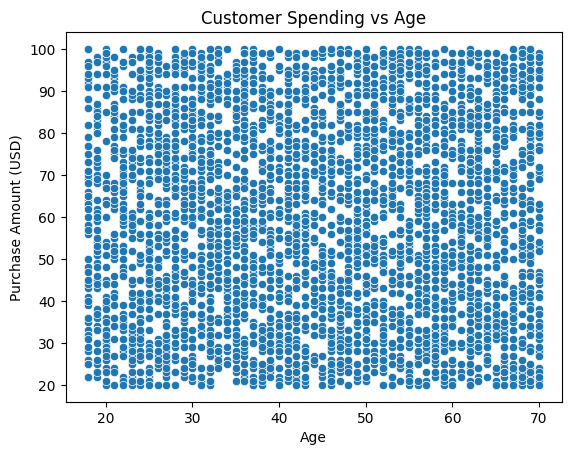

In [68]:
sns.scatterplot(x="age", y="purchase_amount_(usd)", data=df)

plt.title("Customer Spending vs Age")
plt.xlabel("Age")
plt.ylabel("Purchase Amount (USD)")

plt.show()

## Business Insights

From the analysis, several insights emerge:

1. Certain product categories contribute significantly to overall revenue.
2. Customer demographics influence purchasing behavior.
3. Seasonal trends affect purchase patterns.
4. Payment methods reveal customer transaction preferences.
5. Predictive modeling can help forecast customer spending behavior.

## Conclusion

This project analyzed customer shopping behavior using data analytics and machine learning techniques.

Key contributions include:

- Data cleaning and preprocessing
- Exploratory data analysis
- Customer segmentation
- Predictive modeling

These insights can help businesses improve marketing strategies, optimize product offerings, and enhance customer engagement.

## SQL-Based Business Analysis

In addition to Python-based analysis, SQL is used to perform structured queries on the dataset to extract business insights.

The dataset is loaded into a SQLite database, allowing SQL queries to analyze customer behavior and purchasing patterns efficiently.

This section focuses on answering key business questions such as:
- What is the total revenue generated from customer purchases?
- Which product categories contribute the most to sales?
- How does customer spending vary across demographics?
- Which payment methods are most frequently used?


In [70]:
import sqlite3

In [71]:
conn = sqlite3.connect("customer_shopping.db")

In [72]:
df.to_sql("customers", conn, if_exists="replace", index=False)

3900

### Total Revenue

This query calculates the total revenue generated from all customer purchases in the dataset.

Understanding total revenue helps provide a baseline for evaluating business performance and comparing different customer segments.

In [73]:
query = """
SELECT SUM([purchase_amount_(usd)]) AS total_revenue
FROM customers
"""

pd.read_sql_query(query, conn)

,total_revenue
0,233081


### Revenue by Product Category

This query analyzes total revenue generated by each product category.

The results help identify:
- The most profitable product categories
- Customer preferences for specific product types
- Opportunities to optimize inventory and marketing strategies

In [74]:
query = """
SELECT category,
SUM([purchase_amount_(usd)]) AS revenue
FROM customers
GROUP BY category
ORDER BY revenue DESC
"""

pd.read_sql_query(query, conn)

,category,revenue
0,1,104264
1,0,74200
2,2,36093
3,3,18524


### Average Spending by Gender

This query compares the average purchase amount between different gender groups.

Analyzing gender-based spending helps reveal:
- Differences in purchasing behavior
- Demographic spending patterns
- Opportunities for targeted marketing campaigns

In [75]:
query = """
SELECT gender,
AVG([purchase_amount_(usd)]) AS avg_spending
FROM customers
GROUP BY gender
"""

pd.read_sql_query(query, conn)

,gender,avg_spending
0,0,60.249199
1,1,59.536199


### Seasonal Sales Analysis

This query examines how sales vary across different seasons.

Seasonal analysis helps businesses:
- Identify peak sales periods
- Understand seasonal demand trends
- Plan marketing campaigns and inventory management accordingly

In [76]:
query = """
SELECT season,
SUM([purchase_amount_(usd)]) AS seasonal_sales
FROM customers
GROUP BY season
ORDER BY seasonal_sales DESC
"""

pd.read_sql_query(query, conn)

,season,seasonal_sales
0,0,60018
1,1,58679
2,3,58607
3,2,55777


### Payment Method Usage

This query determines the most commonly used payment methods among customers.

Understanding payment preferences helps businesses:
- Optimize checkout processes
- Promote preferred payment options
- Improve customer convenience during transactions

In [77]:
query = """
SELECT payment_method,
COUNT(*) AS usage_count
FROM customers
GROUP BY payment_method
ORDER BY usage_count DESC
"""

pd.read_sql_query(query, conn)

,payment_method,usage_count
0,PayPal,677
1,Credit Card,671
2,Cash,670
3,Debit Card,636
4,Venmo,634
5,Bank Transfer,612


### SQL Insights Summary

The SQL queries provide structured insights into customer purchasing behavior and sales performance.

These insights help businesses understand revenue drivers, customer preferences, and transaction patterns, supporting data-driven decision-making.

### Closing Database Connection

After completing all SQL queries, the database connection is closed to properly release resources.

In [78]:
conn.close()